In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

In [3]:
path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_HM.xlsx"
df = pd.read_excel(path)

df = df.groupby('Class').mean()
df = df.reset_index()

In [4]:
def encodage(df):
    code = {
    'LP' : 'IL',
    'SP' : 'IO',
    'LN' : 'HL',
    'SN' : 'HO'
}
    # Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df

encodage(df)
df = df.set_index('Class')
print(df.shape)
df.head()

(4, 385)


,(-)-Caryophyllene oxide,(-)-Citronellal,(-)-Isopulegol,(+/-)-6-Acetonyldihydrosanguinarine,(+/-)9-HpODE,"(12Z)-9,10,11-trihydroxyoctadec-12-enoic acid","(13S,14R)-1,8-Dihydroxy-13-O-acetyl-N-methylcanadine","(1R,2R)-3-oxo-2-pentyl-cyclopentanebutanoic acid","(20S,24S)-24-ethylthornasterol","(2R,3S,4S,5R,6R)-2-(hydroxymethyl)-6-(2-phenylethoxy)oxane-3,4,5-triol",...,Coniferin,Deoxylimononic acid D-ring-lactone,Ferulaldehyde,Marmesin,Methyleugenol,Naringenin chalcone,Neohesperidin,Phloridzin,trans-Anethole,Isoscopoletin
Class,,,,,,,,,,,,,,,,,,,,,
HL,1.591455e+07,6.980138e+07,5.631014e+07,1.449034e+08,4.335375e+06,8.535153e+06,1.766983e+06,2.648956e+08,4.355494e+06,9.664745e+06,...,6.939086e+06,9.162016e+06,9.633634e+06,1.243857e+06,1.430837e+07,4.043855e+05,9.217758e+05,1.039302e+05,9.407254e+06,1.201708e+07
IL,2.952731e+07,4.659259e+07,1.455664e+08,1.789006e+08,8.626689e+06,8.261674e+06,1.720943e+06,2.538358e+08,1.398658e+06,1.363532e+07,...,1.412598e+07,1.032705e+07,2.302739e+07,3.747008e+05,1.629475e+07,9.016501e+05,2.773134e+06,8.109454e+04,1.632331e+07,2.627377e+07
HO,3.621271e+06,1.318311e+07,3.954817e+06,5.627351e+07,3.468366e+07,4.204084e+06,9.390267e+06,8.327545e+08,1.263292e+07,6.627322e+06,...,1.595483e+06,3.026178e+05,2.108045e+06,6.058752e+06,6.325601e+06,1.799970e+07,1.997852e+07,6.915266e+06,3.236706e+07,3.292818e+07
IO,6.650474e+06,5.141848e+06,4.719063e+06,6.386797e+07,2.463304e+07,6.653567e+06,1.203525e+07,1.060611e+09,4.606290e+06,1.585956e+07,...,5.709360e+06,2.334481e+05,2.683576e+06,7.488058e+06,6.642415e+06,1.396005e+07,1.816003e+07,1.907657e+06,1.899205e+07,7.890817e+07


In [5]:
print('var before log2 : ', df.var(axis=0).median())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
df = log2_transformer.fit_transform(df)
print('var after log2 : ', df.var(axis=0).median())

var before log2 :  192088589387855.22
var after log2 :  2.2951121796831857


In [6]:
ca = ["Syringin","Coniferin","Methyleugenol","L-Phenylalanine","L-Tyrosine","Cinnamic acid","p-Coumaric acid","Ferulic acid","Sinapic acid","Ferulaldehyde", "4,5-Dicaffeoylquinic acid"]
cm = ["Marmesin","Scopolin","Scopoletin","Esculetin","Heraclenol","7-Demethylsuberosin","Isopimpinellin","Byakangelicin","Imperatorin","Xanthotoxol","Byakangelicol","Phellopterin", "Isoscopoletin"]
fn = ["Baimaside","Naringenin chalcone","Lonicerin","Rhoifolin","Apigenin","Vitexin","Isovitexin","Vitexin rhamnoside","Quercetin","Rutin","Quercitrin","Isoquercitrin","Apigetrin","Cynaroside","Astragalin","Kaempferol","Nicotiflorin"]
ln = ["Deoxylimononic acid D-ring-lactone","Limonin glucoside","Limonin","Limonoate","Nomilin","Obacunoic acid","Obacunone"]
df_ca = df[ca]
df_cm = df[cm]
df_fn = df[fn]
df_ln = df[ln]
#df_bm = df[bm]

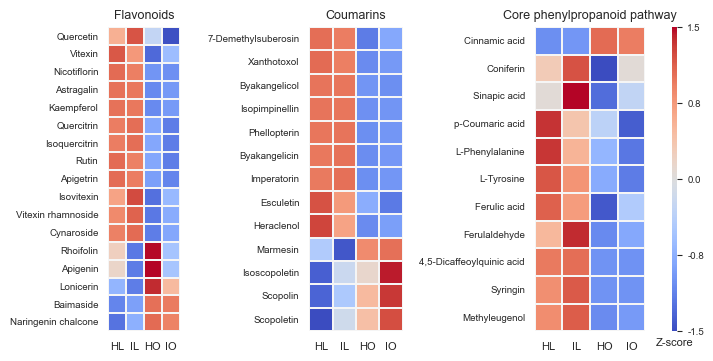

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# ==================================================
# GLOBAL STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

sns.set_style("white")

# ==================================================
# HELPERS
# ==================================================
def zscore_by_metabolite(df):
    mat = df.T.copy() if df.shape[1] > df.shape[0] else df.copy()
    mu = mat.mean(axis=1)
    sd = mat.std(axis=1, ddof=0).replace(0, np.nan)
    Z = (mat.sub(mu, axis=0)).div(sd, axis=0)
    return Z.replace([np.inf, -np.inf], np.nan).fillna(0)

def cluster_order_rows(Z):
    dist = pdist(Z.values, metric="euclidean")
    L = linkage(dist, method="average")
    return dendrogram(L, no_plot=True)["leaves"]

# ==================================================
# DATA
# ==================================================
Z_ca = zscore_by_metabolite(df_ca)
Z_cm = zscore_by_metabolite(df_cm)
Z_fn = zscore_by_metabolite(df_fn)

col_order = ["HL", "IL", "HO", "IO"]
Z_ca = Z_ca[col_order]
Z_cm = Z_cm[col_order]
Z_fn = Z_fn[col_order]

# ==================================================
# SHARED COLOR SCALE
# ==================================================
all_vals = np.concatenate([
    Z_ca.values.ravel(),
    Z_cm.values.ravel(),
    Z_fn.values.ravel()
])

abs_lim = np.nanpercentile(np.abs(all_vals), 98)
vmin, vmax = -abs_lim, abs_lim
cmap = sns.color_palette("coolwarm", as_cmap=True)

# ==================================================
# CLUSTERING
# ==================================================
Z_fn_plot = Z_fn.iloc[cluster_order_rows(Z_fn), :]
Z_cm_plot = Z_cm.iloc[cluster_order_rows(Z_cm), :]
Z_ca_plot = Z_ca.iloc[cluster_order_rows(Z_ca), :]

# ==================================================
# FIGURE (CONSTRAINED LAYOUT!)
# ==================================================
fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 3.5),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.05]},
    constrained_layout=True
)

ax1, ax2, ax3, cax = axes

# ==================================================
# HEATMAPS
# ==================================================
common_kws = dict(
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    center=0,
    linewidths=0.15,
    linecolor="#F5F5F5",
    cbar=False,
    square = True
)

sns.heatmap(Z_fn_plot, ax=ax1, **common_kws)
sns.heatmap(Z_cm_plot, ax=ax2, **common_kws)
sns.heatmap(Z_ca_plot, ax=ax3, **common_kws)

# ==================================================
# CLEAN AXES
# ==================================================
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

ax1.set_title("Flavonoids", fontsize=9, pad=6)
ax2.set_title("Coumarins", fontsize=9, pad=6)
ax3.set_title("Core phenylpropanoid pathway", fontsize=9, pad=6)

# ==================================================
# COLORBAR
# ==================================================
mappable = ax1.collections[0]
cb = fig.colorbar(mappable, cax=cax)

# Supprimer le titre au-dessus
cax.set_title("")

# Placer "Z-score" sous la barre (centré)
cax.text(
    0.5, -0.02, "Z-score",
    ha="center",
    va="top",
    transform=cax.transAxes,
    fontsize=8
)

for spine in cax.spines.values():
    spine.set_visible(False)

ticks = np.linspace(vmin, vmax, 5)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])

out_pdf = r"C:/Users/tamer/Documents/PhD/ML/Heatmap/Heatmaps_3panel.pdf"

fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [7]:
stop

NameError: name 'stop' is not defined

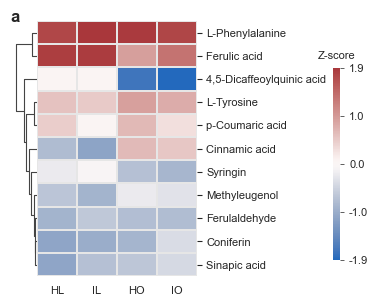

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# GLOBAL STYLE (journal-like)
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")  # clean background

# ==================================================
# INPUT
# df_ca: metabolites x samples (or whatever you have)
# You are using df_ca.T in your code -> keep that logic.
# ==================================================
# df_ca = ...

data = df_ca.T  # rows = samples, cols = metabolites (as in your example)

# --------------------------------------------------
# Z-score by metabolite (across samples) -> like z_score=0 but explicit control
# --------------------------------------------------
Z = (data - data.mean(axis=0)) / data.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0)

# --------------------------------------------------
# Symmetric color limits (robust) to avoid 1–2 outliers dominating
# --------------------------------------------------
abs_lim = np.nanpercentile(np.abs(Z.values), 98)  # robust 98th percentile
vmin, vmax = -abs_lim, abs_lim

# ==================================================
# COLORMAP (high IF default)
# - "vlag" is clean; alternatives: "RdBu_r", "coolwarm"
# ==================================================
cmap = sns.color_palette("vlag", as_cmap=True)

# ==================================================
# CLUSTERMAP
# ==================================================
g = sns.clustermap(
    Z,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=0,
    row_cluster=True,
    col_cluster=False,
    method="average",
    metric="euclidean",
    linewidths=0.25,
    linecolor="#E6E6E6",
    dendrogram_ratio=(0.12, 0.02),
    cbar_pos=(0.985, 0.20, 0.02, 0.60),  # <-- x plus à droite
    figsize=(3.35, 3.2)
)

# ==================================================
# CLEAN AXES / TICKS
# ==================================================
# Remove heatmap axis labels
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# X labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, ha="center", fontsize=8)

# Y labels (metabolites)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# Make dendrogram lines thinner and black/grey (not dominant)
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(0.8)
        line.set_color("#444444")

# Remove spines everywhere (clean look)
for ax in [g.ax_heatmap, g.ax_row_dendrogram, g.ax_col_dendrogram, g.cax]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# ==================================================
# COLORBAR STYLE
# ==================================================
g.cax.tick_params(labelsize=8, width=0.6, length=3, color="#444444")
g.cax.set_title("Z-score", fontsize=8, pad=6)

# Optional: fewer ticks (cleaner)
ticks = np.linspace(vmin, vmax, 5)
g.cax.set_yticks(ticks)
g.cax.set_yticklabels([f"{t:.1f}" for t in ticks])

# ==================================================
# OPTIONAL: Panel label (top-left)
# ==================================================
g.fig.text(0.02, 0.98, "a", fontsize=12, fontweight="bold", va="top", ha="left")

# ==================================================
# OPTIONAL: Rename sample labels to 2-line (prettier)
# ==================================================
# Example if your sample names are like "Lemon control" etc.
# new_xticks = ["Lemon\ncontrol", "Lemon\ninoculated", "Orange\ncontrol", "Orange\ninoculated"]
# g.ax_heatmap.set_xticklabels(new_xticks)

# ==================================================
# EXPORT
# ==================================================
out_pdf = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.pdf"
out_png = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.png"

g.fig.savefig(out_pdf, bbox_inches="tight")
g.fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# GLOBAL STYLE (journal-like)
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")  # clean background

# ==================================================
# INPUT
# df_ca: metabolites x samples (or whatever you have)
# You are using df_ca.T in your code -> keep that logic.
# ==================================================
# df_ca = ...

data = df_cm.T  # rows = samples, cols = metabolites (as in your example)

# --------------------------------------------------
# Z-score by metabolite (across samples) -> like z_score=0 but explicit control
# --------------------------------------------------
Z = (data - data.mean(axis=0)) / data.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0)

# --------------------------------------------------
# Symmetric color limits (robust) to avoid 1–2 outliers dominating
# --------------------------------------------------
abs_lim = np.nanpercentile(np.abs(Z.values), 98)  # robust 98th percentile
vmin, vmax = -abs_lim, abs_lim

# ==================================================
# COLORMAP (high IF default)
# - "vlag" is clean; alternatives: "RdBu_r", "coolwarm"
# ==================================================
cmap = sns.color_palette("vlag", as_cmap=True)

# ==================================================
# CLUSTERMAP
# ==================================================
g = sns.clustermap(
    Z,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=0,
    row_cluster=True,
    col_cluster=False,
    method="average",
    metric="euclidean",
    linewidths=0.25,
    linecolor="#E6E6E6",
    dendrogram_ratio=(0.12, 0.02),
    cbar_pos=(0.985, 0.20, 0.02, 0.60),  # <-- x plus à droite
    figsize=(4.2, 3.4)
)

# ==================================================
# CLEAN AXES / TICKS
# ==================================================
# Remove heatmap axis labels
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# X labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, ha="center", fontsize=8)

# Y labels (metabolites)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# Make dendrogram lines thinner and black/grey (not dominant)
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(0.8)
        line.set_color("#444444")

# Remove spines everywhere (clean look)
for ax in [g.ax_heatmap, g.ax_row_dendrogram, g.ax_col_dendrogram, g.cax]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# ==================================================
# COLORBAR STYLE
# ==================================================
g.cax.tick_params(labelsize=8, width=0.6, length=3, color="#444444")
g.cax.set_title("Z-score", fontsize=8, pad=6)

# Optional: fewer ticks (cleaner)
ticks = np.linspace(vmin, vmax, 5)
g.cax.set_yticks(ticks)
g.cax.set_yticklabels([f"{t:.1f}" for t in ticks])

# ==================================================
# OPTIONAL: Panel label (top-left)
# ==================================================
g.fig.text(0.02, 0.98, "a", fontsize=12, fontweight="bold", va="top", ha="left")

# ==================================================
# OPTIONAL: Rename sample labels to 2-line (prettier)
# ==================================================
# Example if your sample names are like "Lemon control" etc.
# new_xticks = ["Lemon\ncontrol", "Lemon\ninoculated", "Orange\ncontrol", "Orange\ninoculated"]
# g.ax_heatmap.set_xticklabels(new_xticks)

# ==================================================
# EXPORT
# ==================================================
out_pdf = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.pdf"
out_png = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.png"

g.fig.savefig(out_pdf, bbox_inches="tight")
g.fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# GLOBAL STYLE (journal-like)
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")  # clean background

# ==================================================
# INPUT
# df_ca: metabolites x samples (or whatever you have)
# You are using df_ca.T in your code -> keep that logic.
# ==================================================
# df_ca = ...

data = df_fn.T  # rows = samples, cols = metabolites (as in your example)

# --------------------------------------------------
# Z-score by metabolite (across samples) -> like z_score=0 but explicit control
# --------------------------------------------------
Z = (data - data.mean(axis=0)) / data.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0)

# --------------------------------------------------
# Symmetric color limits (robust) to avoid 1–2 outliers dominating
# --------------------------------------------------
abs_lim = np.nanpercentile(np.abs(Z.values), 98)  # robust 98th percentile
vmin, vmax = -abs_lim, abs_lim

# ==================================================
# COLORMAP (high IF default)
# - "vlag" is clean; alternatives: "RdBu_r", "coolwarm"
# ==================================================
cmap = sns.color_palette("vlag", as_cmap=True)

# ==================================================
# CLUSTERMAP
# ==================================================
g = sns.clustermap(
    Z,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=0,
    row_cluster=True,
    col_cluster=False,
    method="average",
    metric="euclidean",
    linewidths=0.25,
    linecolor="#E6E6E6",
    dendrogram_ratio=(0.12, 0.02),
    cbar_pos=(0.985, 0.20, 0.02, 0.60),  # <-- x plus à droite
    figsize=(4.2, 3.4)
)

# ==================================================
# CLEAN AXES / TICKS
# ==================================================
# Remove heatmap axis labels
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# X labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, ha="center", fontsize=8)

# Y labels (metabolites)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# Make dendrogram lines thinner and black/grey (not dominant)
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(0.8)
        line.set_color("#444444")

# Remove spines everywhere (clean look)
for ax in [g.ax_heatmap, g.ax_row_dendrogram, g.ax_col_dendrogram, g.cax]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# ==================================================
# COLORBAR STYLE
# ==================================================
g.cax.tick_params(labelsize=8, width=0.6, length=3, color="#444444")
g.cax.set_title("Z-score", fontsize=8, pad=6)

# Optional: fewer ticks (cleaner)
ticks = np.linspace(vmin, vmax, 5)
g.cax.set_yticks(ticks)
g.cax.set_yticklabels([f"{t:.1f}" for t in ticks])

# ==================================================
# OPTIONAL: Panel label (top-left)
# ==================================================
g.fig.text(0.02, 0.98, "a", fontsize=12, fontweight="bold", va="top", ha="left")

# ==================================================
# OPTIONAL: Rename sample labels to 2-line (prettier)
# ==================================================
# Example if your sample names are like "Lemon control" etc.
# new_xticks = ["Lemon\ncontrol", "Lemon\ninoculated", "Orange\ncontrol", "Orange\ninoculated"]
# g.ax_heatmap.set_xticklabels(new_xticks)

# ==================================================
# EXPORT
# ==================================================
out_pdf = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.pdf"
out_png = "C:/Users/tamer/Documents/PhD/ML/Heatmap/HCA_heatmap_highIF.png"

g.fig.savefig(out_pdf, bbox_inches="tight")
g.fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

Final column order: ['HL', 'IL', 'HO', 'IO']


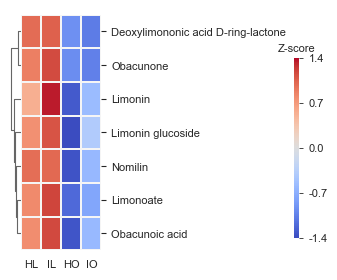

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# GLOBAL STYLE (Journal-ready)
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")

# ==================================================
# INPUT
# df_ln must contain metabolites x samples OR samples x metabolites
# ==================================================
# df_ln = ...

# ==================================================
# Z-SCORE BY METABOLITE (robust orientation-safe)
# ==================================================
def zscore_by_metabolite(df):
    """
    Ensures Z-score is computed per metabolite (row-wise).
    Automatically detects orientation.
    """

    # If samples are rows (e.g. HL, IL, HO, IO)
    # then transpose so metabolites are rows
    if set(["HL", "IL", "HO", "IO"]).issubset(df.index):
        mat = df.T.copy()
    else:
        mat = df.copy()

    # Compute Z per metabolite (row)
    mu = mat.mean(axis=1)
    sd = mat.std(axis=1, ddof=0).replace(0, np.nan)

    Z = mat.sub(mu, axis=0).div(sd, axis=0)
    Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0)

    return Z

Z = zscore_by_metabolite(df_ln)

# ==================================================
# FORCE COLUMN ORDER (critical for interpretation)
# ==================================================
col_order = ["HL", "IL", "HO", "IO"]
Z = Z[col_order]

# Optional debug check (remove later)
print("Final column order:", Z.columns.tolist())

# ==================================================
# ROBUST SYMMETRIC COLOR SCALE
# ==================================================
abs_lim = np.nanpercentile(np.abs(Z.values), 98)
vmin, vmax = -abs_lim, abs_lim

# Cleaner colormap with whiter center
cmap = sns.color_palette("coolwarm", as_cmap=True)

# ==================================================
# CLUSTERMAP
# ==================================================
g = sns.clustermap(
    Z,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    center=0,
    row_cluster=True,
    col_cluster=False,
    method="average",
    metric="euclidean",
    linewidths=0.15,
    linecolor="#F5F5F5",
    dendrogram_ratio=(0.12, 0.02),
    cbar_pos=(0.985, 0.20, 0.02, 0.60),
    figsize=(3.0, 3.0)
)

# ==================================================
# FORCE WHITE BACKGROUND (fix grey impression)
# ==================================================
g.fig.patch.set_facecolor("white")
g.ax_heatmap.set_facecolor("white")

# ==================================================
# CLEAN AXES
# ==================================================
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

plt.setp(g.ax_heatmap.get_xticklabels(),
         rotation=0, ha="center", fontsize=8)

plt.setp(g.ax_heatmap.get_yticklabels(),
         rotation=0, fontsize=8)

# ==================================================
# LIGHTER DENDROGRAM (less dominant)
# ==================================================
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(0.8)
        line.set_color("#666666")

# Remove all spines
for ax in [g.ax_heatmap, g.ax_row_dendrogram,
           g.ax_col_dendrogram, g.cax]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# ==================================================
# COLORBAR STYLE
# ==================================================
g.cax.set_title("Z-score", fontsize=8, pad=4)

ticks = np.linspace(vmin, vmax, 5)
g.cax.set_yticks(ticks)
g.cax.set_yticklabels([f"{t:.1f}" for t in ticks])
g.cax.tick_params(labelsize=8, width=0.6, length=3)

# Remove colorbar outline if present
try:
    g.cax.collections[0].colorbar.outline.set_visible(False)
except:
    pass

# ==================================================
# EXPORT
# ==================================================
out_pdf = "C:/Users/tamer/Documents/PhD/ML/Heatmap/Heatmap_limonoids.pdf"
out_png = "C:/Users/tamer/Documents/PhD/ML/Heatmap/Heatmap_limonoids.png"

g.fig.savefig(out_pdf, bbox_inches="tight")
g.fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
#color = sns.color_palette("Spectral", as_cmap=True)

g = sns.clustermap(df.T,
                   cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/CA_heatmap.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/CA_heatmap.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)

plt.show()

In [ ]:
#color = sns.color_palette("Spectral", as_cmap=True)

g = sns.clustermap(df_cm.T,
                   cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/coumarins_heatmap.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/coumarins_heatmap.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)

plt.show()

In [ ]:
#color = sns.color_palette("Spectral", as_cmap=True)

g = sns.clustermap(df_fn.T,
                   cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/flavonoids_heatmap.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/flavonoids_heatmap.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)

plt.show()

In [ ]:
#color = sns.color_palette("Spectral", as_cmap=True)

g = sns.clustermap(df_ln.T,
                   cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/Limonoids_heatmap.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/Limonoids_heatmap.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)

plt.show()

In [ ]:
#color = sns.color_palette("Spectral", as_cmap=True)

g = sns.clustermap(df_bm.T,
                   cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/biomarkers_heatmap.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/Heatmap/biomarkers_heatmap.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)

plt.show()

In [ ]:
lpsp = ["Chuanxiongoside A",
"Flavonol 3-O-D-xylosylgalactoside;",
"Fraxinellone",
"Vaccarin",
"[(2R,3S,4S,5R,6R)-3,4,5-trihydroxy-6-{[(2R,3R,4S,5S,6R)-3,4,5-trihydroxy-6-({[(2E)-2-methylbut-2-enoyl]oxy}methyl)oxan-2-yl]oxy}oxan-2-yl]methyl (2E)-2-methylbut-2-enoate",
"2-hydroxy-6-[2-hydroxy-6-(hydroxymethyl)-4-methoxyphenoxy]-4-methylbenzoic acid",
"4,5-Dicaffeoylquinic acid",
"4-[3-(4-hydroxy-3-methoxybenzoyl)-2,3-dimethyloxirane-2-carbonyl]-2-methoxyphenol",
"6-O-Pentopyranosyl-1-O-[(2,6,6-trimethyl-1-cyclohexen-1-yl)carbonyl]-beta-D-glucopyranose",
"Adiantifoline;",
"Astragalin",
"Chrysosplenetin B",
"Didymin",
"Gardenin B",
"Iridin",
"Isoquercitrin",
"Isradipine",
"Kaempferol",
"Kaempferol 3-apiosyl-(1->4)-rhamnoside-7-rhamnoside",
"Kaempferol-3-O-rutinoside",
"Phaseolic acid;",
"Purifolin",
"Rutin",
"Sibiricose A1",
"Zeatin-7-N-glucoside"
]

lpln = ["(2E)-3-(4-{[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy}phenyl)prop-2-enoic acid",
"(2S,3R,4S,5S,6R)-2-(4,6-dihydroxy-2-nonyl-3-{[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy}phenoxy)-6-(hydroxymethyl)oxane-3,4,5-triol",
"1-(8-hydroxy-3-methyl-1-{[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy}naphthalen-2-yl)ethan-1-one",
"13(S)-HOTrE",
"1-Ethyl-6,7-dimethoxyisoquinolin-3-ol",
"22-dimethylarsinoyl-(5Z,8Z, 11Z,14Z,17Z,20Z)-docosahexaenoic acid",
"2-C-Methyl-D-erythritol 4-phosphate;",
"3-{2-[(1R,4aS,5R,6R,8aS)-6-hydroxy-5-(hydroxymethyl)-5,8a-dimethyl-2-methylidene-decahydronaphthalen-1-yl]-1-hydroxyethyl}-2,5-dihydrofuran-2-one",
"3-hydroxy-2-[3-methyl-2-({[3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy}methyl)cyclopent-2-en-1-yl]propanoic acid",
"3-Hydroxy-2-methyl-4-[(7-oxo-7H-furo[3,2-g]chromen-4-yl)oxy]-2-butanyl beta-D-glucopyranoside",
"4-{3-[(4-hydroxy-3-methoxyphenyl)methyl]-2-methylbutyl}benzene-1,2-diol",
"4-O-beta-D-Glucosyl-sinapate;",
"Asparagine",
"Bilobalide",
"C-13(2)-Carboxypyropheophorbide a; C-13(2)-Carboxylpyropheophorbide a;",
"Coroglaucigenin-3-o-alpha-L-rhamnopyranoside;",
"Glucosyl-limonin; Limonin 17-beta-D-glucoside;",
"Haplophytine;",
"L-Ascorbic acid-2-glucoside; AA-2G;",
"Methyl (2R)-[(1S,3S,7R,8R,12S,13S)-13-(3-furyl)-6,6,8,12-tetramethyl-17-methylene-5,15-dioxo-2,14-dioxatetracyclo[7.7.1.01,12 03,8]heptadec-7-yl](hydroxy)acetate",
"Chuanxiongoside A",
"Flavonol 3-O-D-xylosylgalactoside;",
"Fraxinellone",
"Vaccarin"
]


In [ ]:
df_lpln = df[lpln]
df_lpsp = df[lpsp]